# Breast Cancer Detection on Full Screening Mammography with DenseNet121

A reproducible, state-of-the-art transfer learning pipeline for benign vs malignant classification on the Curated Breast Imaging Subset of DDSM (CBIS-DDSM).

**Architectural & Methodological Decisions for First-Class Accuracy:**

1. **DenseNet121 Transfer Learning (Two-Stage):** Utilizes DenseNet121 for maximum feature reuse, preserving microscopic indicators like microcalcifications deep into the network. Employs a strict two-stage training methodology (head warm-up followed by targeted unfreezing from `conv4_block`) with batch normalization protection to prevent catastrophic forgetting.

2. **Fused CLAHE & Artifact Masking:** Integrates Contrast Limited Adaptive Histogram Equalization (CLAHE) to enhance medical-grade tissue contrast, mathematically fused with an OpenCV contour-masking function to isolate the breast and erase scanner artifacts (eliminating "Clever Hans" shortcut learning).

3. **High-Resolution Processing:** Processes images at 512x512 to preserve microscopic malignant features on full, uncropped mammograms.

4. **Spatial Attention & Dual Pooling:** Features a custom spatial attention block to focus on dense tissue, paired with a concatenated Global Average and Global Max Pooling head to preserve both background context and high-intensity anomalies.

5. **Gradient-Free Explainability:** Employs Score-CAM heatmaps for robust visual diagnostic verification, cleanly bypassing architectural gradient-tracing disconnections.

**Runtime:**
Written for Google Colab with an L4 GPU. Set `Runtime > Change runtime type > L4 GPU` before running. Due to the 512x512 resolution, the batch size is optimized for L4 memory limits.

In [1]:
# Cell 1: Install Dependencies
!pip install -q kagglehub opencv-python-headless
print("Installs complete.")

Installs complete.


In [2]:
# Cell 2: Core Imports and GPU Verification
import os
import re
import json
import glob
import random
import warnings
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
import cv2

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input

from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

print("TensorFlow :", tf.__version__)
print("GPU found  :", tf.config.list_physical_devices("GPU"))

TensorFlow : 2.20.0
GPU found  : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Cell 3: Configuration Object (Optimized for Deep Domain Adaptation)
@dataclass
class Config:
    seed: int = 1337
    image_kind: str = "full"
    img_size: tuple = (512, 512)
    batch_size: int = 16

    val_patient_fraction: float = 0.15

    # Training Schedule
    head_epochs: int = 10
    finetune_epochs: int = 40
    patience: int = 15
    head_lr: float = 1e-3
    finetune_lr: float = 1e-5

    # Architecture & Regularization
    dense_units: int = 256
    dropout: float = 0.5
    l2_lambda: float = 1e-4

    # Deep Unfreezing: Unfreeze from conv4_block to adapt mid-level textures
    unfreeze_prefix: str = "conv4_block"

    # CLAHE Contrast Parameters
    clahe_clip: float = 2.0
    clahe_grid: tuple = (8, 8)

    # Aggressive Augmentation
    aug_rotation: float = 0.15
    aug_zoom: float = 0.20
    aug_contrast: float = 0.15
    aug_translation: float = 0.10

CFG = Config()

def set_all_seeds(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_all_seeds(CFG.seed)
WORK_DIR = "/content/work"
MODEL_DIR = os.path.join(WORK_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)
print("Configuration updated for Deep Unfreezing & CLAHE.")

Configuration updated for Deep Unfreezing & CLAHE.


In [4]:
# Cell 4: Download Dataset
import kagglehub
print("Downloading CBIS-DDSM (cached after first run)...")
RAW_ROOT = kagglehub.dataset_download("awsaf49/cbis-ddsm-breast-cancer-image-dataset")
CSV_DIR = glob.glob(os.path.join(RAW_ROOT, "**", "dicom_info.csv"), recursive=True)[0]
CSV_DIR = os.path.dirname(CSV_DIR)
print("CSV directory:", CSV_DIR)

Using Colab cache for faster access to the 'cbis-ddsm-breast-cancer-image-dataset' dataset.
CSV directory: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/csv


In [5]:
# Cell 5: Clinical Metadata Extraction
UID_PATTERN = re.compile(r"\d+(?:\.\d+){5,}")

def normalise_columns(df):
    df.columns = [str(c).strip().lower().replace(" ", "_") for c in df.columns]
    return df

case_files = sorted(glob.glob(os.path.join(CSV_DIR, "*case_description*.csv")))
uid_records = {}

for path in case_files:
    df = normalise_columns(pd.read_csv(path))
    for _, row in df.iterrows():
        pathology = str(row.get("pathology", "")).upper()
        label = 1 if "MALIGNANT" in pathology else 0

        # Isolate Full Mammograms
        if "image_file_path" in df.columns:
            uids = UID_PATTERN.findall(str(row.get("image_file_path", "")))
            for uid in uids:
                uid_records[uid] = {"label": label, "role": "full"}

print(f"Mapped {len(uid_records)} unique Full Mammogram UIDs to labels.")

Mapped 6206 unique Full Mammogram UIDs to labels.


In [6]:
# Cell 6: Manifest Generation
dicom = pd.read_csv(os.path.join(CSV_DIR, "dicom_info.csv"), low_memory=False)
JPEG_ROOT = os.path.join(RAW_ROOT, "jpeg")

dicom["abs_path"] = dicom["image_path"].astype(str).str.replace("CBIS-DDSM/jpeg", JPEG_ROOT, regex=False)
dicom["series_uid"] = dicom["abs_path"].apply(lambda p: os.path.basename(os.path.dirname(str(p))))

meta_df = pd.DataFrame.from_dict(uid_records, orient="index").reset_index(names="series_uid")
manifest = dicom.merge(meta_df, on="series_uid", how="inner")
manifest = manifest[manifest["abs_path"].apply(os.path.exists)].copy()

print(f"Final Manifest contains {len(manifest)} valid full mammogram images.")

Final Manifest contains 3103 valid full mammogram images.


In [7]:
# Cell 7: Image Preprocessing (CLAHE + Artifact Masking)
def enhance_and_mask_opencv(img_np):
    """
    Applies CLAHE for contrast enhancement, finds the breast contour,
    and masks out scanner artifacts.
    """
    # 1. Cast to uint8
    img_uint8 = np.clip(img_np, 0, 255).astype(np.uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

    # 2. Masking
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return img_np.astype(np.float32)

    largest_contour = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

    # 3. Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=CFG.clahe_clip, tileGridSize=CFG.clahe_grid)
    enhanced_gray = clahe.apply(gray)

    # 4. Convert back to RGB and apply the mask
    enhanced_rgb = cv2.cvtColor(enhanced_gray, cv2.COLOR_GRAY2RGB)
    masked_img = cv2.bitwise_and(enhanced_rgb, enhanced_rgb, mask=mask)

    return masked_img.astype(np.float32)

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, CFG.img_size)

    # Apply fused CLAHE & Masking
    img = tf.numpy_function(enhance_and_mask_opencv, [img], tf.float32)
    img.set_shape([CFG.img_size[0], CFG.img_size[1], 3])

    img = preprocess_input(img)
    return img, label

# Patient-Level Splitting & TF Pipeline setup remains identical
from sklearn.model_selection import train_test_split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    manifest["abs_path"].values, manifest["label"].values,
    test_size=CFG.val_patient_fraction, random_state=CFG.seed, stratify=manifest["label"].values
)

classes = np.unique(train_labels)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_labels)
class_weight_dict = dict(zip(classes, weights))

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels)).map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE).shuffle(buffer_size=500).batch(CFG.batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels)).map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(CFG.batch_size).prefetch(tf.data.AUTOTUNE)

In [8]:
# Cell 8: Build DenseNet121 Model with Spatial Attention & Dual Pooling
def build_densenet_model():
    inputs = keras.Input(shape=(CFG.img_size[0], CFG.img_size[1], 3))

    # Data Augmentation
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(CFG.aug_rotation)(x)
    x = layers.RandomZoom(CFG.aug_zoom)(x)
    x = layers.RandomTranslation(CFG.aug_translation, CFG.aug_translation)(x)

    # DenseNet121 Base (Frozen for Stage 1)
    base_model = DenseNet121(include_top=False, weights='imagenet', input_tensor=x)
    base_model.trainable = False
    features = base_model.output

    # Spatial Attention Mechanism
    attention = layers.Conv2D(1, (1, 1), padding='same', activation='sigmoid')(features)
    attended_features = layers.Multiply()([features, attention])

    # Dual Pooling Head: Preserves both background context (Avg) and high-intensity anomalies (Max)
    gap = layers.GlobalAveragePooling2D()(attended_features)
    gmp = layers.GlobalMaxPooling2D()(attended_features)
    x = layers.Concatenate()([gap, gmp])

    x = layers.Dense(CFG.dense_units, activation='relu', kernel_regularizer=keras.regularizers.l2(CFG.l2_lambda))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(CFG.dropout)(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_densenet_model()

model.compile(optimizer=keras.optimizers.Adam(learning_rate=CFG.head_lr),
              loss='binary_crossentropy',
              metrics=['accuracy', keras.metrics.AUC(name='auc')])

print("DenseNet121 Model built with Dual Pooling. Base is FROZEN for Stage 1.")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
DenseNet121 Model built with Dual Pooling. Base is FROZEN for Stage 1.


In [9]:
# Cell 9: Two-Stage Training Loop (With Batch Norm Protection)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=CFG.patience,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        mode='max',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print(f"--- STAGE 1: Warming up Classification Head for {CFG.head_epochs} Epochs ---")
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CFG.head_epochs,
    class_weight=class_weight_dict,
    verbose=1
)

print(f"\n--- STAGE 2: Unfreezing from {CFG.unfreeze_prefix} and Fine-Tuning ---")

# Targeted Unfreezing with Batch Norm Protection
base_model.trainable = True
unfreeze = False

for layer in base_model.layers:
    if CFG.unfreeze_prefix in layer.name:
        unfreeze = True

    # Crucial: Keep BatchNormalization layers frozen to prevent weight collapse
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = unfreeze

# Stage 2 Compilation
model.compile(optimizer=keras.optimizers.Adam(learning_rate=CFG.finetune_lr),
              loss='binary_crossentropy',
              metrics=['accuracy', keras.metrics.AUC(name='auc')])

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CFG.finetune_epochs,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

--- STAGE 1: Warming up Classification Head for 10 Epochs ---
Epoch 1/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 80s 306ms/step - accuracy: 0.5313 - auc: 0.5356 - loss: 0.8920 - val_accuracy: 0.5622 - val_auc: 0.5782 - val_loss: 0.7146
Epoch 2/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 48s 259ms/step - accuracy: 0.5597 - auc: 0.5699 - loss: 0.7790 - val_accuracy: 0.4785 - val_auc: 0.5967 - val_loss: 0.8492
Epoch 3/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 49s 263ms/step - accuracy: 0.5620 - auc: 0.5979 - loss: 0.7331 - val_accuracy: 0.5515 - val_auc: 0.6008 - val_loss: 0.7279
Epoch 4/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 49s 261ms/step - accuracy: 0.5973 - auc: 0.6380 - loss: 0.6991 - val_accuracy: 0.5815 - val_auc: 0.6188 - val_loss: 0.7014
Epoch 5/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 49s 261ms/step - accuracy: 0.6056 - auc: 0.6466 - loss: 0.6861 - val_accuracy: 0.5558 - val_auc: 0.6215 - val_loss: 0.6937
Epoch 6/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 49s 261ms/step - accuracy: 0.6090 - auc: 0.6358 - loss: 0.6922 - val_accuracy: 0.55

In [10]:
# Cell 10: Generate Predictions
val_preds = model.predict(val_ds)
val_preds_binary = (val_preds > 0.5).astype(int)

print("Classification Report:")
print(classification_report(val_labels, val_preds_binary, target_names=["Benign", "Malignant"]))

30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 311ms/step
Classification Report:
              precision    recall  f1-score   support

      Benign       0.75      0.68      0.71       260
   Malignant       0.64      0.71      0.67       206

    accuracy                           0.69       466
   macro avg       0.69      0.69      0.69       466
weighted avg       0.70      0.69      0.69       466



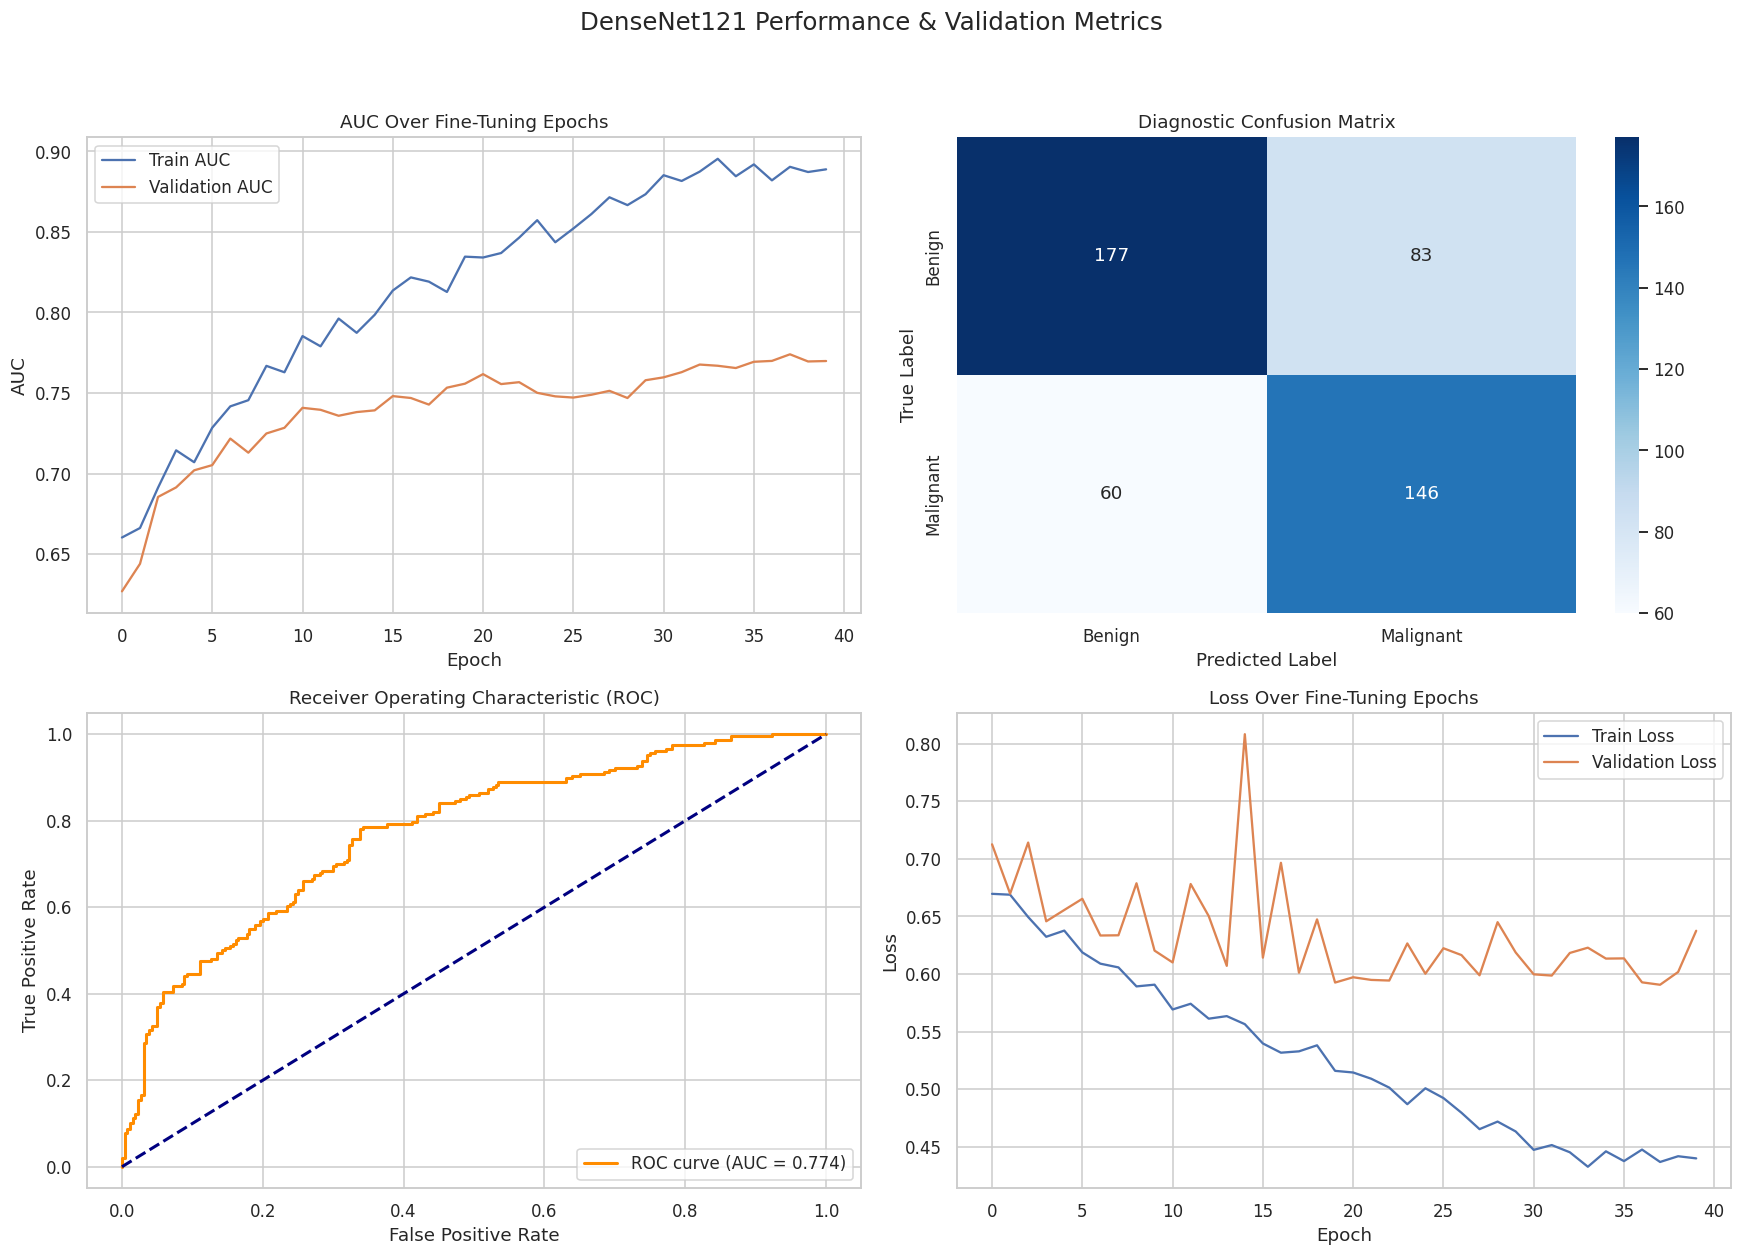

In [11]:
# Cell 11: Render Analytics Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('DenseNet121 Performance & Validation Metrics', fontsize=16)

# 1. Training vs Validation AUC
auc = history_finetune.history['auc']
val_auc = history_finetune.history['val_auc']
axes[0, 0].plot(auc, label='Train AUC')
axes[0, 0].plot(val_auc, label='Validation AUC')
axes[0, 0].set_title('AUC Over Fine-Tuning Epochs')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('AUC')
axes[0, 0].legend()

# 2. Confusion Matrix
cm = confusion_matrix(val_labels, val_preds_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[0, 1].set_title('Diagnostic Confusion Matrix')
axes[0, 1].set_xlabel('Predicted Label')
axes[0, 1].set_ylabel('True Label')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(val_labels, val_preds)
roc_auc = roc_auc_score(val_labels, val_preds)
axes[1, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1, 0].set_title('Receiver Operating Characteristic (ROC)')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].legend(loc="lower right")

# 4. Loss Curve
loss = history_finetune.history['loss']
val_loss = history_finetune.history['val_loss']
axes[1, 1].plot(loss, label='Train Loss')
axes[1, 1].plot(val_loss, label='Validation Loss')
axes[1, 1].set_title('Loss Over Fine-Tuning Epochs')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Running Score-CAM over 1024 feature channels... (Processing...)


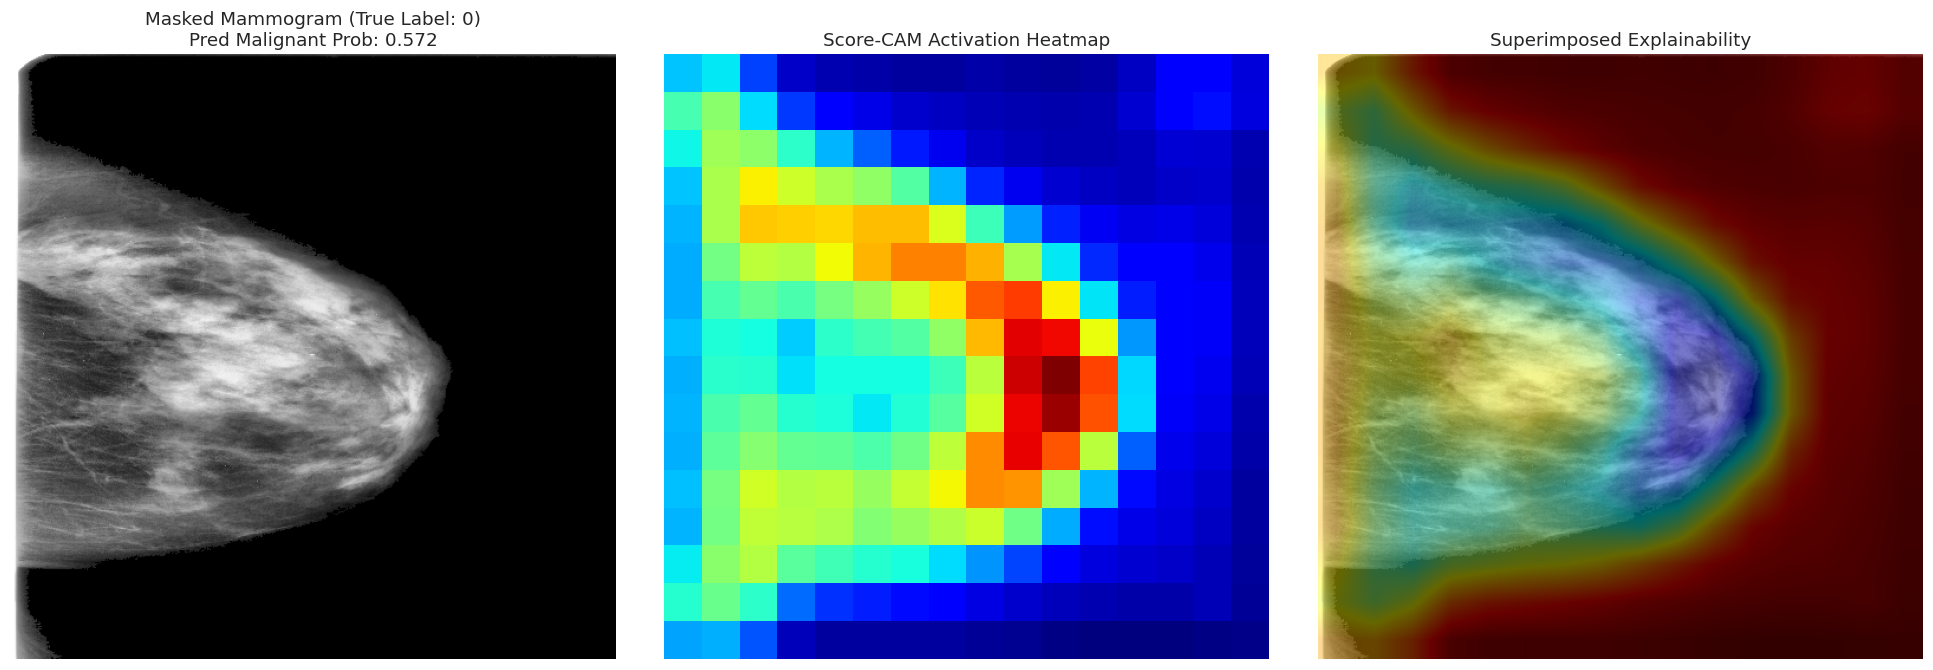

In [13]:
# Cell 12: Gradient-Free Explainability Visualization (Score-CAM)
def make_scorecam_heatmap(img_tensor, model, last_conv_layer_name, batch_size=16):

    # 1. Feature Extractor (Directly from main model)
    last_conv_layer = model.get_layer(last_conv_layer_name)
    feature_extractor = keras.Model(inputs=model.inputs, outputs=last_conv_layer.output)

    # 2. Extract activation maps
    activations = feature_extractor(img_tensor, training=False)[0]
    num_channels = activations.shape[-1]

    # 3. Transpose & Upsample to 512x512
    act_transposed = tf.transpose(activations, [2, 0, 1])
    act_transposed = tf.expand_dims(act_transposed, axis=-1)
    upsampled = tf.image.resize(act_transposed, (img_tensor.shape[1], img_tensor.shape[2]))

    # Normalize channels to [0, 1] for masking
    max_vals = tf.reduce_max(upsampled, axis=(1, 2, 3), keepdims=True)
    min_vals = tf.reduce_min(upsampled, axis=(1, 2, 3), keepdims=True)
    norm_activations = (upsampled - min_vals) / (max_vals - min_vals + 1e-7)

    # 4. Base prediction mapping
    base_pred = model(img_tensor, training=False)[0, 0].numpy()
    target_class_is_malignant = base_pred > 0.5

    # 5. Iterative forward pass (Batched to prevent GPU OOM)
    scores = []
    print(f"Running Score-CAM over {num_channels} feature channels... (Processing...)")

    for i in range(0, num_channels, batch_size):
        batch_masks = norm_activations[i:i+batch_size]
        masked_imgs = img_tensor * batch_masks

        batch_preds = model(masked_imgs, training=False)

        if target_class_is_malignant:
            batch_scores = batch_preds[:, 0]
        else:
            batch_scores = 1.0 - batch_preds[:, 0]

        scores.extend(batch_scores.numpy())

    scores = tf.convert_to_tensor(scores)
    scores = tf.nn.softmax(scores)

    # 6. Final Heatmap via Linear Combination
    weighted_activations = activations * tf.reshape(scores, (1, 1, num_channels))
    heatmap = tf.reduce_sum(weighted_activations, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    max_h = tf.reduce_max(heatmap)
    min_h = tf.reduce_min(heatmap)

    if max_h > min_h:
        heatmap = (heatmap - min_h) / (max_h - min_h + 1e-10)
    else:
        heatmap = tf.zeros_like(heatmap)

    return heatmap.numpy(), base_pred

# Load Sample
sample_path = val_paths[0]
sample_label = val_labels[0]
img_tensor, _ = load_and_preprocess(sample_path, sample_label)
img_tensor = tf.expand_dims(img_tensor, axis=0)

# Generate Heatmap (DenseNet121's final activation layer before pooling is 'relu')
heatmap, pred_score = make_scorecam_heatmap(img_tensor, model, "relu", batch_size=CFG.batch_size)

# Extract and apply the exact OpenCV mask for visualization consistency
img_raw = cv2.imread(sample_path)
img_raw = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
img_raw = cv2.resize(img_raw, CFG.img_size)

# FIXED: Use the updated CLAHE + Masking function name
img_raw = enhance_and_mask_opencv(img_raw)
img_raw = img_raw.astype(np.uint8)

# Format Heatmap
heatmap_resized = cv2.resize(heatmap, (img_raw.shape[1], img_raw.shape[0]))
heatmap_resized_uint8 = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized_uint8, cv2.COLORMAP_JET)

# Superimpose
superimposed_img = cv2.addWeighted(img_raw, 0.6, heatmap_color, 0.4, 0)

# Render Dashboard
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(img_raw)
ax[0].set_title(f"Masked Mammogram (True Label: {sample_label})\nPred Malignant Prob: {pred_score:.3f}")
ax[0].axis('off')

ax[1].imshow(heatmap, cmap='jet')
ax[1].set_title("Score-CAM Activation Heatmap")
ax[1].axis('off')

ax[2].imshow(superimposed_img)
ax[2].set_title("Superimposed Explainability")
ax[2].axis('off')

plt.tight_layout()
plt.show()